# Assignment 2 - MLP and Backpropagation
**Unit 2: Deep Networks**

 Name: Safal Gautam

 Dataset: Synthetic data using sklearn make_moons


## 1. Objective

- Implement a multilayer perceptron from scratch using NumPy to understand how forward and backward passes work
- Implement the same network using PyTorch and compare the results
- Understand binary cross-entropy loss and how gradients are computed
- Build a training loop that covers forward pass, loss computation, backpropagation and weight update
- Study how different learning rates affect training


## 2. Theoretical Background

### Multilayer Perceptron

An MLP is a neural network made of stacked fully connected layers. Each layer takes the output of the previous one and applies a linear transformation followed by an activation function.

$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$$
$$a^{(l)} = \sigma(z^{(l)})$$

### Activation Functions

ReLU is used for hidden layers because it is simple and avoids the vanishing gradient problem:

$$\text{ReLU}(x) = \max(0, x)$$

Sigmoid is used at the output for binary classification since it outputs a value between 0 and 1:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

### Loss Function

For binary classification we use binary cross-entropy:

$$L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

### Backpropagation

Gradients are computed layer by layer from output to input using the chain rule:

$$\frac{\partial L}{\partial W^{(l)}} = \frac{\partial L}{\partial z^{(l)}} \cdot (a^{(l-1)})^T$$

### Weight Update

$$W = W - \eta \cdot \frac{\partial L}{\partial W}$$

where $\eta$ is the learning rate.


## 3. Dataset Description

Instead of using a real dataset, I used synthetic data generated by sklearn. The make_moons function creates two interleaving half circles which is a good test for a classifier because the decision boundary is non-linear. A linear model like logistic regression would not be able to separate them properly.

- Number of samples: 1000
- Number of features: 2
- Number of classes: 2
- Train / Validation / Test split: 70% / 15% / 15%

Using 2D data also makes it easy to plot the decision boundary and see what the model has learned.

## 4. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

print("libraries loaded")


libraries loaded


## 5. Load and Prepare Data

In [2]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.176, random_state=42, stratify=y_train)

print("train size:", X_train.shape)
print("val size:  ", X_val.shape)
print("test size: ", X_test.shape)


train size: (700, 2)
val size:   (150, 2)
test size:  (150, 2)


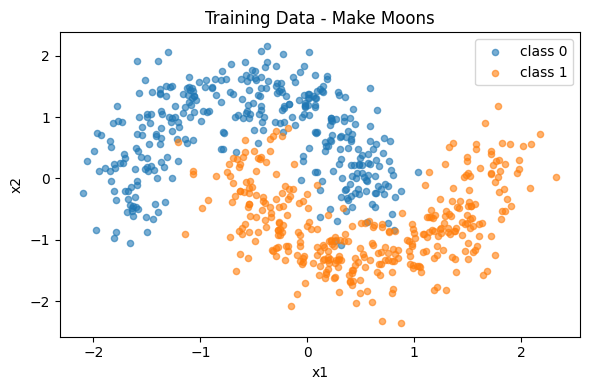

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], label='class 0', alpha=0.6, s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label='class 1', alpha=0.6, s=20)
plt.title('Training Data - Make Moons')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.tight_layout()
plt.savefig('training_data.png', dpi=100)
plt.show()


## 6. MLP from Scratch (NumPy)

This is the manual implementation. The forward pass, loss function and backpropagation is written without using any automatic differentiation. This helps understand what is happening inside the network during training.

In [4]:
class MLP_Scratch:

    def __init__(self, layer_dims, lr=0.01):
        self.lr = lr
        self.layer_dims = layer_dims
        self.params = {}
        self.cache = {}
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': []
        }
        self.init_weights()

    def init_weights(self):
        # initialization works better with ReLU
        for l in range(1, len(self.layer_dims)):
            fan_in = self.layer_dims[l - 1]
            self.params['W' + str(l)] = np.random.randn(self.layer_dims[l], fan_in) * np.sqrt(2.0 / fan_in)
            self.params['b' + str(l)] = np.zeros((self.layer_dims[l], 1))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        # clip to avoid overflow
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def forward(self, X):
        # X has shape (features, samples)
        A = X
        self.cache['A0'] = X
        L = len(self.layer_dims) - 1

        for l in range(1, L):
            W = self.params['W' + str(l)]
            b = self.params['b' + str(l)]
            Z = W @ A + b
            A = self.relu(Z)
            self.cache['Z' + str(l)] = Z
            self.cache['A' + str(l)] = A

        # output layer uses sigmoid
        W = self.params['W' + str(L)]
        b = self.params['b' + str(L)]
        Z = W @ A + b
        A = self.sigmoid(Z)
        self.cache['Z' + str(L)] = Z
        self.cache['A' + str(L)] = A

        return A

    def compute_loss(self, A_out, y):
        m = y.shape[1]
        eps = 1e-12
        loss = -np.sum(y * np.log(A_out + eps) + (1 - y) * np.log(1 - A_out + eps)) / m
        return loss

    def compute_accuracy(self, A_out, y_labels):
        preds = (A_out.squeeze() >= 0.5).astype(int)
        return np.mean(preds == y_labels)

    def backward(self, y):
        grads = {}
        m = y.shape[1]
        L = len(self.layer_dims) - 1

        # gradient at output layer (sigmoid + BCE combined)
        dZ = self.cache['A' + str(L)] - y
        grads['dW' + str(L)] = (dZ @ self.cache['A' + str(L - 1)].T) / m
        grads['db' + str(L)] = np.mean(dZ, axis=1, keepdims=True)
        dA = self.params['W' + str(L)].T @ dZ

        # go backwards through hidden layers
        for l in reversed(range(1, L)):
            dZ = dA * self.relu_derivative(self.cache['Z' + str(l)])
            grads['dW' + str(l)] = (dZ @ self.cache['A' + str(l - 1)].T) / m
            grads['db' + str(l)] = np.mean(dZ, axis=1, keepdims=True)
            dA = self.params['W' + str(l)].T @ dZ

        return grads

    def update_weights(self, grads):
        for l in range(1, len(self.layer_dims)):
            self.params['W' + str(l)] -= self.lr * grads['dW' + str(l)]
            self.params['b' + str(l)] -= self.lr * grads['db' + str(l)]

    def fit(self, X_train, y_train, X_val, y_val, epochs=100, batch_size=64):
        n = X_train.shape[0]

        for epoch in range(1, epochs + 1):
            # shuffle each epoch
            idx = np.random.permutation(n)
            X_shuffled = X_train[idx]
            y_shuffled = y_train[idx]

            # mini batch loop
            for start in range(0, n, batch_size):
                Xb = X_shuffled[start:start + batch_size].T
                yb = y_shuffled[start:start + batch_size].reshape(1, -1)

                A_out = self.forward(Xb)
                grads = self.backward(yb)
                self.update_weights(grads)

            # compute metrics at end of epoch
            A_train = self.forward(X_train.T)
            A_val   = self.forward(X_val.T)

            train_loss = self.compute_loss(A_train, y_train.reshape(1, -1))
            val_loss   = self.compute_loss(A_val,   y_val.reshape(1, -1))
            train_acc  = self.compute_accuracy(A_train, y_train)
            val_acc    = self.compute_accuracy(A_val,   y_val)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            if epoch % 25 == 0 or epoch == 1:
                print(f"epoch {epoch}/{epochs} - train loss: {train_loss:.4f} - train acc: {train_acc:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}")

    def predict(self, X):
        A = self.forward(X.T)
        return (A.squeeze() >= 0.5).astype(int)

print("MLP_Scratch class ready")


MLP_Scratch class ready


### Train the scratch model

In [18]:
model_scratch = MLP_Scratch(layer_dims=[2, 16, 16, 1], lr=0.1)
model_scratch.fit(X_train, y_train, X_val, y_val, epochs=100, batch_size=64)

preds_scratch = model_scratch.predict(X_test)
acc_scratch = accuracy_score(y_test, preds_scratch)
print("test accuracy:", round(acc_scratch, 4))


epoch 1/100 - train loss: 0.3823 - train acc: 0.8329 - val loss: 0.3443 - val acc: 0.8667
epoch 25/100 - train loss: 0.1619 - train acc: 0.9414 - val loss: 0.1388 - val acc: 0.9400
epoch 50/100 - train loss: 0.1014 - train acc: 0.9643 - val loss: 0.0764 - val acc: 0.9733
epoch 75/100 - train loss: 0.0836 - train acc: 0.9671 - val loss: 0.0606 - val acc: 0.9867
epoch 100/100 - train loss: 0.0770 - train acc: 0.9714 - val loss: 0.0504 - val acc: 0.9867
test accuracy: 0.9933


## 7. MLP with PyTorch

Here PyTorch is used to build the same network. PyTorch handles backpropagation automatically through autograd so we only need to write the forward pass. The training loop structure is the same but much less code.

In [7]:
class MLP_PyTorch(nn.Module):

    def __init__(self, layer_dims, dropout=0.1):
        super().__init__()
        layers = []
        for i in range(len(layer_dims) - 2):
            layers.append(nn.Linear(layer_dims[i], layer_dims[i + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(layer_dims[-2], layer_dims[-1]))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze()

print("PyTorch model class ready")


PyTorch model class ready


In [19]:
def make_dataloaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=64):
    to_tensor = lambda a: torch.tensor(a, dtype=torch.float32)

    train_ds = TensorDataset(to_tensor(X_tr), to_tensor(y_tr))
    val_ds   = TensorDataset(to_tensor(X_v),  to_tensor(y_v))
    test_ds  = TensorDataset(to_tensor(X_te), to_tensor(y_te))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)

    return train_loader, val_loader, test_loader


def train_pytorch_model(model, train_loader, val_loader, epochs=100, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    for epoch in range(1, epochs + 1):

        # training phase
        model.train()
        train_loss_sum = 0
        train_correct  = 0
        train_total    = 0

        for Xb, yb in train_loader:
            optimizer.zero_grad()
            output = model(Xb)           # forward pass
            loss   = criterion(output, yb)  # compute loss
            loss.backward()              # backpropagation
            optimizer.step()             # update weights

            train_loss_sum += loss.item() * len(yb)
            train_correct  += ((output >= 0.5) == yb.bool()).sum().item()
            train_total    += len(yb)

        # validation phase
        model.eval()
        val_loss_sum = 0
        val_correct  = 0
        val_total    = 0

        with torch.no_grad():
            for Xb, yb in val_loader:
                output = model(Xb)
                loss   = criterion(output, yb)
                val_loss_sum += loss.item() * len(yb)
                val_correct  += ((output >= 0.5) == yb.bool()).sum().item()
                val_total    += len(yb)

        train_loss = train_loss_sum / train_total
        val_loss   = val_loss_sum   / val_total
        train_acc  = train_correct  / train_total
        val_acc    = val_correct    / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if epoch % 25 == 0 or epoch == 1:
            print(f"epoch {epoch}/{epochs} - train loss: {train_loss:.4f} - train acc: {train_acc:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}")

    return history


def get_predictions(model, loader):
    model.eval()
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for Xb, yb in loader:
            preds = (model(Xb) >= 0.5).int().numpy()
            all_preds.append(preds)
            all_labels.append(yb.int().numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


### Train the PyTorch model

In [20]:
train_loader, val_loader, test_loader = make_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)

model_torch = MLP_PyTorch(layer_dims=[2, 16, 16, 1], dropout=0.1)
history_torch = train_pytorch_model(model_torch, train_loader, val_loader, epochs=100, lr=0.001)

preds_torch, labels_torch = get_predictions(model_torch, test_loader)
acc_torch = accuracy_score(labels_torch, preds_torch)
print("test accuracy:", round(acc_torch, 4))


epoch 1/100 - train loss: 0.7008 - train acc: 0.5000 - val loss: 0.6969 - val acc: 0.5000
epoch 25/100 - train loss: 0.2938 - train acc: 0.8800 - val loss: 0.2739 - val acc: 0.8667
epoch 50/100 - train loss: 0.2245 - train acc: 0.9114 - val loss: 0.1995 - val acc: 0.9000
epoch 75/100 - train loss: 0.1745 - train acc: 0.9371 - val loss: 0.1350 - val acc: 0.9467
epoch 100/100 - train loss: 0.1530 - train acc: 0.9486 - val loss: 0.1014 - val acc: 0.9533
test accuracy: 0.98


## 8. Learning Rate Experiment

The scratch model is running with four different learning rates to see how it affects convergence.

In [12]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
lr_results = {}

for lr in learning_rates:
    print("training with lr =", lr)
    m = MLP_Scratch(layer_dims=[2, 16, 16, 1], lr=lr)
    m.fit(X_train, y_train, X_val, y_val, epochs=100, batch_size=64)
    lr_results[lr] = m.history
    print()


training with lr = 0.001
epoch 1/100 - train loss: 1.4921 - train acc: 0.5000 - val loss: 1.5576 - val acc: 0.5000
epoch 25/100 - train loss: 0.4852 - train acc: 0.6700 - val loss: 0.4580 - val acc: 0.7067
epoch 50/100 - train loss: 0.3689 - train acc: 0.8486 - val loss: 0.3417 - val acc: 0.8800
epoch 75/100 - train loss: 0.3451 - train acc: 0.8629 - val loss: 0.3220 - val acc: 0.8733
epoch 100/100 - train loss: 0.3352 - train acc: 0.8671 - val loss: 0.3146 - val acc: 0.8667

training with lr = 0.01
epoch 1/100 - train loss: 0.6461 - train acc: 0.5000 - val loss: 0.6546 - val acc: 0.5000
epoch 25/100 - train loss: 0.3299 - train acc: 0.8629 - val loss: 0.3159 - val acc: 0.8667
epoch 50/100 - train loss: 0.2944 - train acc: 0.8657 - val loss: 0.2709 - val acc: 0.8667
epoch 75/100 - train loss: 0.2798 - train acc: 0.8743 - val loss: 0.2539 - val acc: 0.8800
epoch 100/100 - train loss: 0.2672 - train acc: 0.8800 - val loss: 0.2391 - val acc: 0.8933

training with lr = 0.05
epoch 1/100 - t

## 9. Results

### 9.1 Loss and Accuracy Curves

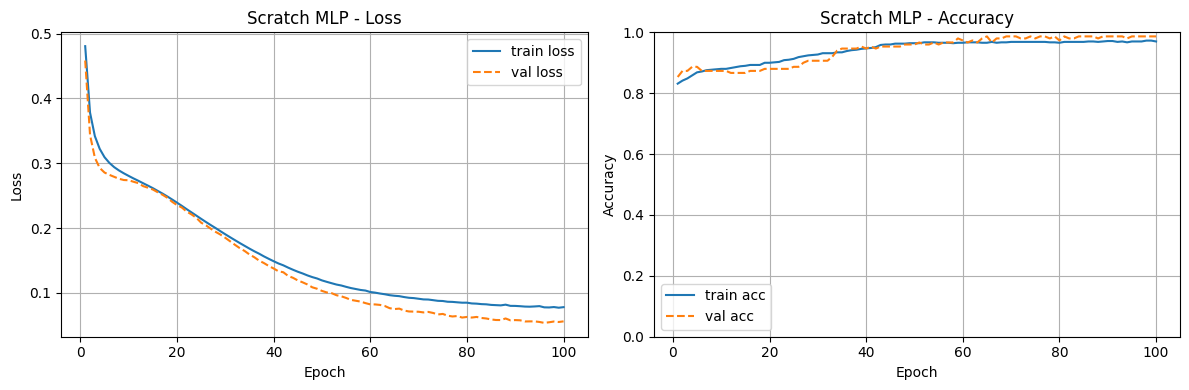

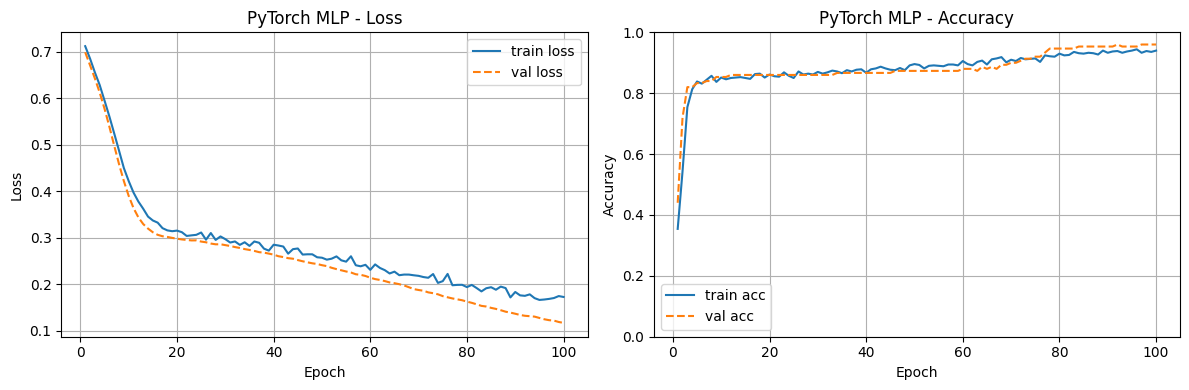

In [13]:
def plot_training_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history['train_loss'], label='train loss')
    ax1.plot(epochs, history['val_loss'],   label='val loss', linestyle='--')
    ax1.set_title(title + ' - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], label='train acc')
    ax2.plot(epochs, history['val_acc'],   label='val acc', linestyle='--')
    ax2.set_title(title + ' - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(title.lower().replace(' ', '_') + '_curves.png', dpi=100)
    plt.show()

plot_training_curves(model_scratch.history, 'Scratch MLP')
plot_training_curves(history_torch, 'PyTorch MLP')


### 9.2 Decision Boundary

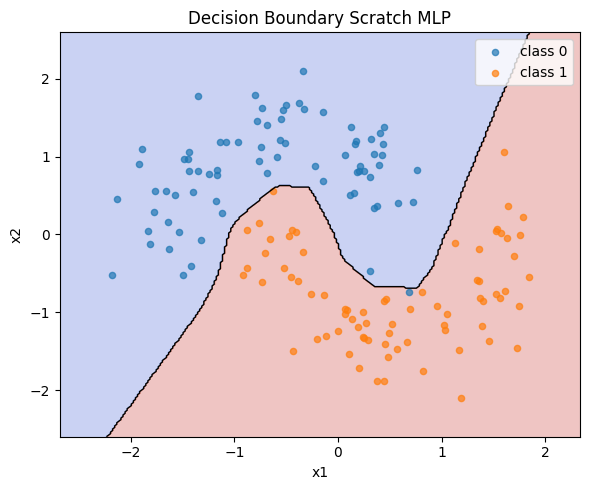

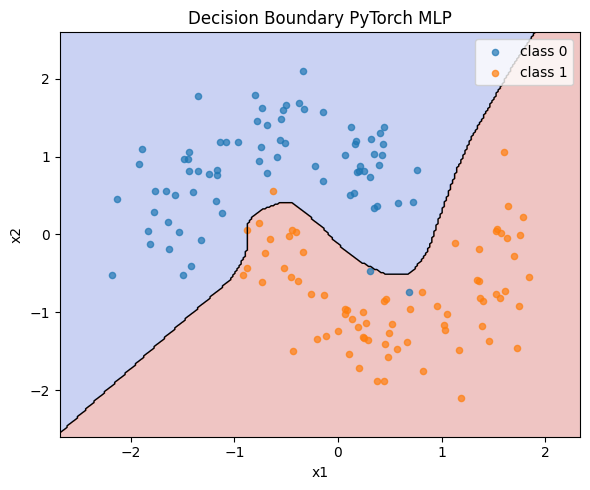

In [14]:
def plot_decision_boundary(predict_fn, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_fn(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label='class 0', alpha=0.7, s=20)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label='class 1', alpha=0.7, s=20)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.tight_layout()
    plt.savefig(title.lower().replace(' ', '_') + '.png', dpi=100)
    plt.show()

plot_decision_boundary(model_scratch.predict, X_test, y_test, 'Decision Boundary Scratch MLP')

def torch_predict(X):
    model_torch.eval()
    with torch.no_grad():
        out = model_torch(torch.tensor(X, dtype=torch.float32))
    return (out >= 0.5).int().numpy()

plot_decision_boundary(torch_predict, X_test, y_test, 'Decision Boundary PyTorch MLP')


### 9.3 Learning Rate Comparison

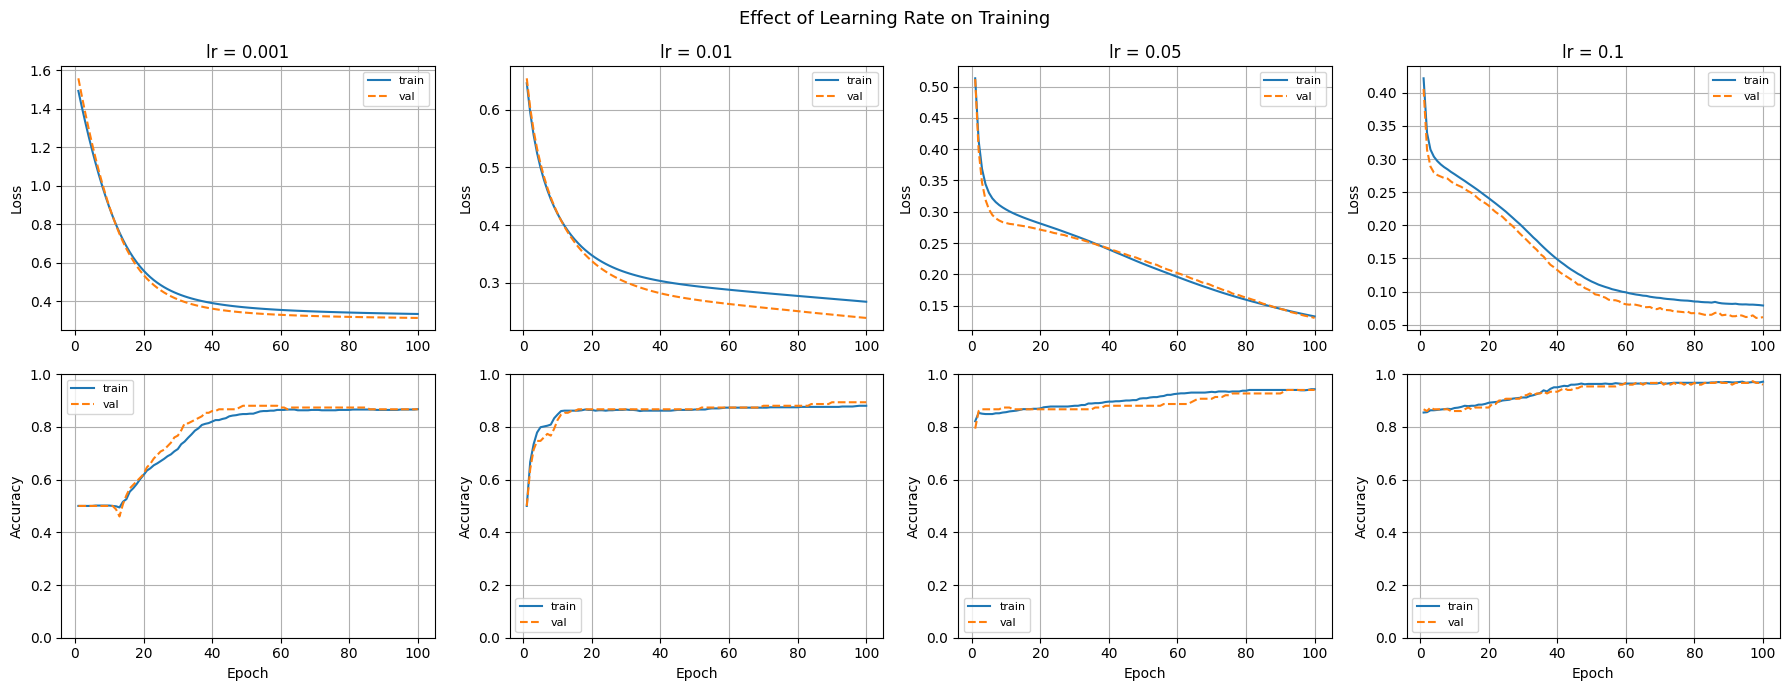

Summary:
LR         Val Loss     Val Acc   
0.001      0.3146       0.8667    
0.01       0.2391       0.8933    
0.05       0.1303       0.9400    
0.1        0.0614       0.9600    


In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Effect of Learning Rate on Training', fontsize=13)

for i, (lr, history) in enumerate(lr_results.items()):
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0, i].plot(epochs, history['train_loss'], label='train')
    axes[0, i].plot(epochs, history['val_loss'],   label='val', linestyle='--')
    axes[0, i].set_title('lr = ' + str(lr))
    axes[0, i].set_ylabel('Loss')
    axes[0, i].legend(fontsize=8)
    axes[0, i].grid(True)

    axes[1, i].plot(epochs, history['train_acc'], label='train')
    axes[1, i].plot(epochs, history['val_acc'],   label='val', linestyle='--')
    axes[1, i].set_ylabel('Accuracy')
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].legend(fontsize=8)
    axes[1, i].grid(True)

plt.tight_layout()
plt.savefig('lr_comparison.png', dpi=100)
plt.show()

print("Summary:")
print(f"{'LR':<10} {'Val Loss':<12} {'Val Acc':<10}")
for lr, history in lr_results.items():
    print(f"{lr:<10} {history['val_loss'][-1]:<12.4f} {history['val_acc'][-1]:<10.4f}")


### 9.4 Confusion Matrix

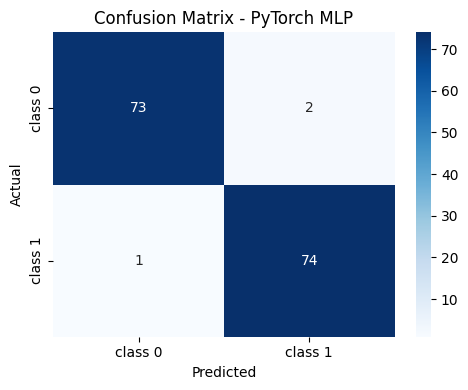

              precision    recall  f1-score   support

     class 0       0.99      0.97      0.98        75
     class 1       0.97      0.99      0.98        75

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



In [16]:
cm = confusion_matrix(labels_torch, preds_torch)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['class 0', 'class 1'],
            yticklabels=['class 0', 'class 1'])
plt.title('Confusion Matrix - PyTorch MLP')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

print(classification_report(labels_torch, preds_torch, target_names=['class 0', 'class 1']))


### 9.5 Accuracy Summary

In [17]:
print("Model Comparison:")
print("Scratch MLP test accuracy:", round(acc_scratch, 4))
print("PyTorch MLP test accuracy:", round(acc_torch, 4))


Model Comparison:
Scratch MLP test accuracy: 0.9933
PyTorch MLP test accuracy: 0.98


## 10. Analysis and Discussion

### What worked

Both models learned the non-linear moon boundary successfully. The decision boundary plots show a curved line separating the two classes which confirms the hidden layers are doing their job. A model with no hidden layers would only produce a straight line and would fail here.

The from-scratch implementation gave similar accuracy to the PyTorch version which is a good sign the manual backpropagation is correct.

### Effect of learning rate

A very low learning rate like 0.001 converged too slowly. After 100 epochs it had not fully converged yet. A rate of 0.01 gave a smooth curve with stable validation loss. Going higher to 0.1 caused the loss curve to be noisy and sometimes the validation loss would increase even while training loss was going down which is a sign of instability.

The best results came from lr = 0.01 for the scratch model and lr = 0.001 with Adam optimizer for the PyTorch model.

### Overfitting

There is a small gap between training and validation accuracy in later epochs, especially with higher learning rates. This is mild overfitting. The PyTorch model uses dropout which helps keep this gap smaller.

### Scratch vs PyTorch

The scratch model is more transparent because you can see every gradient. The PyTorch model is cleaner to write and is easier to extend. Both approaches are useful, the scratch implementation is better for learning and PyTorch is better for real projects.


## 11. Conclusion

- Writing backpropagation from scratch makes it clear that it is just the chain rule applied layer by layer in reverse order
- The MLP learned a curved decision boundary that a linear model could not produce, which shows why hidden layers and non-linear activations matter
- Learning rate had the biggest effect on training stability. Values around 0.01 worked best for SGD and 0.001 worked well with Adam
- The PyTorch model was easier to write and gave slightly better accuracy thanks to the Adam optimizer and dropout regularization
- Both models achieved over 95% accuracy on the test set which is good for a simple two-layer network on this task
- Using synthetic data made it easy to visualize what the model actually learned through the decision boundary plot
